In [ ]:
# Decision Tree Model

# This notebook implements the Decision Tree model for import shipment risk analysis.
# The model is trained without PCA as the final selected approach. PCA was tested separately, but it was not selected because it produced unstable results for this dataset.
# The Decision Tree model is evaluated using three splitting criteria:
#- Gini
#- Entropy
#- Log Loss

In [16]:
from pathlib import Path
import json
import numpy as np
import joblib
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.dummy import DummyClassifier
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    f1_score,
    precision_score,
    recall_score,
)
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree


RANDOM_STATE = 42
TRAINING_SAMPLE_SIZE = 60000
CRITERIA = ["gini", "entropy", "log_loss"]

In [17]:
def find_ml_dir():
    current = Path.cwd().resolve()
    candidates = [current, *current.parents]

    for candidate in candidates:
        direct_dataset = candidate / "data" / "processed" / "cleaned_dataset.csv"
        nested_dataset = candidate / "ml" / "data" / "processed" / "cleaned_dataset.csv"

        if direct_dataset.exists():
            return candidate

        if nested_dataset.exists():
            return candidate / "ml"

    raise FileNotFoundError("Could not find ml/data/processed/cleaned_dataset.csv")


ML_DIR = find_ml_dir()
DATA_PATH = ML_DIR / "data" / "processed" / "cleaned_dataset.csv"
MODELS_DIR = ML_DIR / "models"

MODEL_PATH = MODELS_DIR / "import_risk_decision_tree.joblib"
METRICS_PATH = MODELS_DIR / "decision_tree_metrics.json"
REPORT_PATH = MODELS_DIR / "decision_tree_report.txt"

print("ML directory:", ML_DIR)
print("Dataset path:", DATA_PATH)

ML directory: C:\Users\admin\Desktop\import-risk-analysis-system\ml
Dataset path: C:\Users\admin\Desktop\import-risk-analysis-system\ml\data\processed\cleaned_dataset.csv


In [18]:
df = pd.read_csv(DATA_PATH)

print("Dataset shape:", df.shape)
print("Columns:")
print(df.columns)

display(df.head())

Dataset shape: (263821, 17)
Columns:
Index(['product_name', 'price_usd', 'weight_kg', 'length_m', 'width_m',
       'height_m', 'shipment_date', 'destination_port', 'volume_m3',
       'max_dimension_m', 'dimension_sum_m', 'density_kg_m3', 'value_per_kg',
       'value_per_m3', 'tax', 'tax_ratio', 'risk'],
      dtype='object')


,product_name,price_usd,weight_kg,length_m,width_m,height_m,shipment_date,destination_port,volume_m3,max_dimension_m,dimension_sum_m,density_kg_m3,value_per_kg,value_per_m3,tax,tax_ratio,risk
0,Camera Bag,37.66,1.10,0.40,0.39,0.26,2023-03-19,Port of Singapore (Singapore),0.0406,0.40,1.05,27.1203,34.2364,927.5862,6.26,0.1662,LOW RISK
1,Portable Bluetooth Keyboard,144.65,0.39,0.11,0.06,0.03,2023-03-21,Port of Busan (South Korea),0.0002,0.11,0.20,1969.6970,370.8974,723250.0000,16.76,0.1159,LOW RISK
2,Large Flat Rate Box,38.57,0.97,0.79,0.55,0.35,2023-03-25,Port of Tianjin (China),0.1521,0.79,1.69,6.3784,39.7629,253.5832,6.90,0.1789,LOW RISK
3,Ceramic Tiles,10.34,6.22,0.36,0.37,0.02,2023-03-15,Port of Shanghai (China),0.0027,0.37,0.75,2334.8348,1.6624,3829.6296,1.60,0.1547,LOW RISK
4,Garden Hose,21.63,1.18,17.77,0.27,0.13,2023-03-25,Port of Tianjin (China),0.6237,17.77,18.17,1.8919,18.3305,34.6801,1.39,0.0643,HIGH RISK


In [19]:
print("Missing values:")
display(df.isna().sum())

risk_distribution = (
    df["risk"]
    .value_counts()
    .rename_axis("risk")
    .reset_index(name="count")
)

risk_distribution["percentage"] = (
    risk_distribution["count"] / risk_distribution["count"].sum() * 100
).round(2)

display(risk_distribution)

Missing values:


product_name        0
price_usd           0
weight_kg           0
length_m            0
width_m             0
height_m            0
shipment_date       0
destination_port    0
volume_m3           0
max_dimension_m     0
dimension_sum_m     0
density_kg_m3       0
value_per_kg        0
value_per_m3        0
tax                 0
tax_ratio           0
risk                0
dtype: int64

,risk,count,percentage
0,LOW RISK,224414,85.06
1,HIGH RISK,39407,14.94


In [20]:
def add_tax_bands(df):
    df = df.copy()

    df["tax_band"] = pd.qcut(
        df["tax"],
        q=3,
        labels=False,
        duplicates="drop",
    )

    df["tax_ratio_band"] = pd.qcut(
        df["tax_ratio"],
        q=3,
        labels=False,
        duplicates="drop",
    )

    return df


df = add_tax_bands(df)

display(df[["tax", "tax_band", "tax_ratio", "tax_ratio_band", "risk"]].head())

,tax,tax_band,tax_ratio,tax_ratio_band,risk
0,6.26,1,0.1662,2,LOW RISK
1,16.76,1,0.1159,1,LOW RISK
2,6.90,1,0.1789,2,LOW RISK
3,1.60,0,0.1547,2,LOW RISK
4,1.39,0,0.0643,0,HIGH RISK


In [22]:
FEATURE_COLUMNS = [
    "price_usd",
    "weight_kg",
    "length_m",
    "width_m",
    "height_m",
    "volume_m3",
    "max_dimension_m",
    "dimension_sum_m",
    "density_kg_m3",
    "value_per_kg",
    "value_per_m3",
    "tax_band",
    "tax_ratio_band",
]

print("Features used in Decision Tree:")
for feature in FEATURE_COLUMNS:
    print("-", feature)

Features used in Decision Tree:
- price_usd
- weight_kg
- length_m
- width_m
- height_m
- volume_m3
- max_dimension_m
- dimension_sum_m
- density_kg_m3
- value_per_kg
- value_per_m3
- tax_band
- tax_ratio_band


In [24]:
required_columns = set(FEATURE_COLUMNS + ["risk"])
missing_columns = sorted(required_columns.difference(df.columns))

if missing_columns:
    raise ValueError(f"Missing required columns: {missing_columns}")

print("All required columns are available.")

All required columns are available.


In [25]:
def limit_dataset_size(df, max_rows):
    if len(df) <= max_rows:
        return df.reset_index(drop=True)

    sampled_df, _ = train_test_split(
        df,
        train_size=max_rows,
        random_state=RANDOM_STATE,
        stratify=df["risk"],
    )

    return sampled_df.reset_index(drop=True)


df_model = limit_dataset_size(df, TRAINING_SAMPLE_SIZE)

print(f"Rows used for Decision Tree training: {len(df_model):,}")
display(df_model["risk"].value_counts())

Rows used for Decision Tree training: 60,000


risk
LOW RISK     51038
HIGH RISK     8962
Name: count, dtype: int64

In [26]:
X = df_model[FEATURE_COLUMNS].copy()

y = df_model["risk"].map({
    "HIGH RISK": 1,
    "LOW RISK": 0,
})

if y.isna().any():
    raise ValueError("Risk column contains invalid values.")

print("X shape:", X.shape)
print("y distribution:")
display(y.value_counts().rename(index={0: "LOW RISK", 1: "HIGH RISK"}))

X shape: (60000, 13)
y distribution:


risk
LOW RISK     51038
HIGH RISK     8962
Name: count, dtype: int64

In [27]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=y,
)

print("Training rows:", len(X_train))
print("Testing rows:", len(X_test))

Training rows: 48000
Testing rows: 12000


In [28]:
baseline_model = DummyClassifier(strategy="most_frequent")
baseline_model.fit(X_train, y_train)

baseline_predictions = baseline_model.predict(X_test)
baseline_accuracy = accuracy_score(y_test, baseline_predictions)

print("Baseline accuracy:", round(baseline_accuracy, 4))

Baseline accuracy: 0.8507


In [29]:
def build_decision_tree_model(criterion):
    return DecisionTreeClassifier(
        criterion=criterion,
        max_depth=4,
        min_samples_split=300,
        min_samples_leaf=150,
        class_weight={0: 1, 1: 1.2},
        random_state=RANDOM_STATE,
    )


def evaluate_model(model, X_test, y_test):
    y_pred = model.predict(X_test)

    return {
        "accuracy": round(accuracy_score(y_test, y_pred), 4),
        "precision": round(precision_score(y_test, y_pred, zero_division=0), 4),
        "recall": round(recall_score(y_test, y_pred, zero_division=0), 4),
        "f1_score": round(f1_score(y_test, y_pred, zero_division=0), 4),
        "confusion_matrix": confusion_matrix(y_test, y_pred).tolist(),
        "classification_report": classification_report(
            y_test,
            y_pred,
            target_names=["LOW RISK", "HIGH RISK"],
            zero_division=0,
        ),
    }


trained_models = []

for criterion in CRITERIA:
    model = build_decision_tree_model(criterion)

    print(f"Training Decision Tree with criterion={criterion}...")
    model.fit(X_train, y_train)

    metrics = evaluate_model(model, X_test, y_test)
    metrics["criterion"] = criterion
    metrics["baseline_accuracy"] = round(float(baseline_accuracy), 4)
    metrics["features_used"] = FEATURE_COLUMNS
    metrics["rows_used"] = len(X)
    metrics["test_rows"] = len(X_test)
    metrics["model"] = "Decision Tree"

    trained_models.append((model, metrics))

best_model, best_metrics = max(
    trained_models,
    key=lambda item: (item[1]["f1_score"], item[1]["accuracy"]),
)

print("Best criterion:", best_metrics["criterion"])
print("Accuracy:", best_metrics["accuracy"])
print("Precision:", best_metrics["precision"])
print("Recall:", best_metrics["recall"])
print("F1 Score:", best_metrics["f1_score"])
print("Confusion Matrix:", best_metrics["confusion_matrix"])

Training Decision Tree with criterion=gini...
Training Decision Tree with criterion=entropy...
Training Decision Tree with criterion=log_loss...
Best criterion: gini
Accuracy: 0.8587
Precision: 0.5349
Recall: 0.4107
F1 Score: 0.4646
Confusion Matrix: [[9568, 640], [1056, 736]]


In [30]:
criterion_results = pd.DataFrame([
    {
        "criterion": metrics["criterion"],
        "accuracy": metrics["accuracy"],
        "precision": metrics["precision"],
        "recall": metrics["recall"],
        "f1_score": metrics["f1_score"],
    }
    for _, metrics in trained_models
])

display(criterion_results)

,criterion,accuracy,precision,recall,f1_score
0,gini,0.8587,0.5349,0.4107,0.4646
1,entropy,0.8572,0.5291,0.3956,0.4527
2,log_loss,0.8572,0.5291,0.3956,0.4527


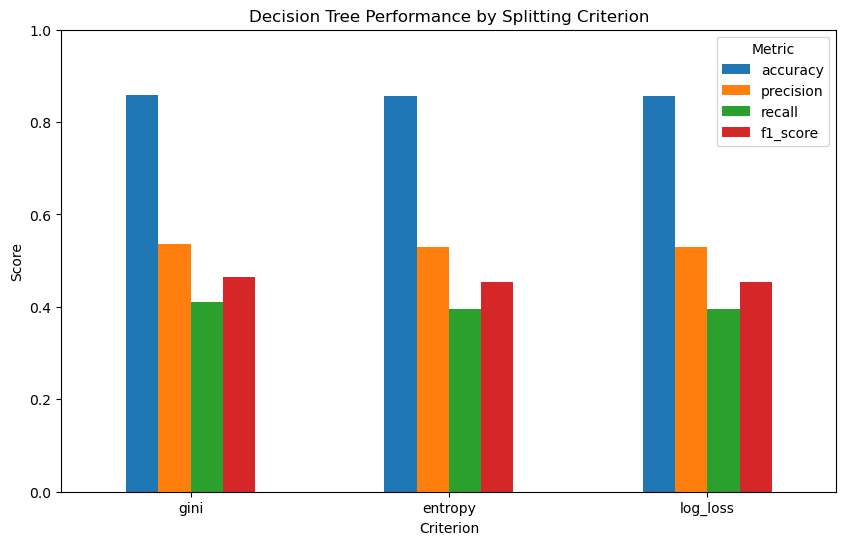

In [31]:
metrics_to_plot = ["accuracy", "precision", "recall", "f1_score"]

criterion_results.set_index("criterion")[metrics_to_plot].plot(
    kind="bar",
    figsize=(10, 6),
)

plt.title("Decision Tree Performance by Splitting Criterion")
plt.xlabel("Criterion")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.xticks(rotation=0)
plt.legend(title="Metric")
plt.show()

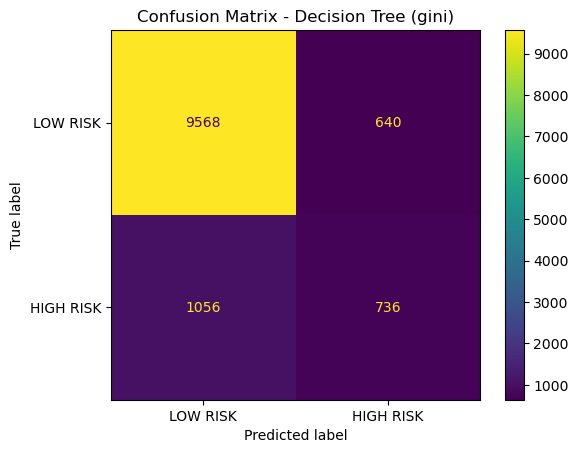

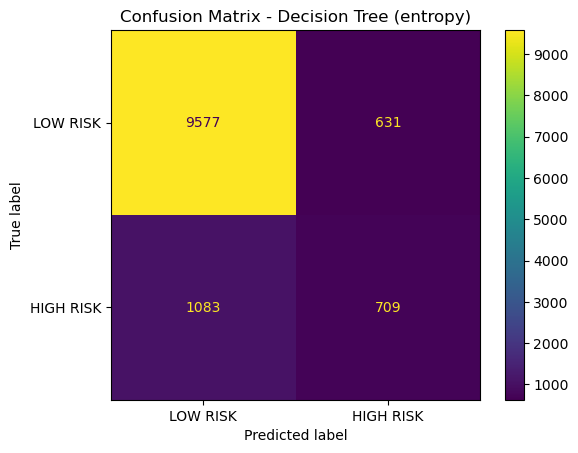

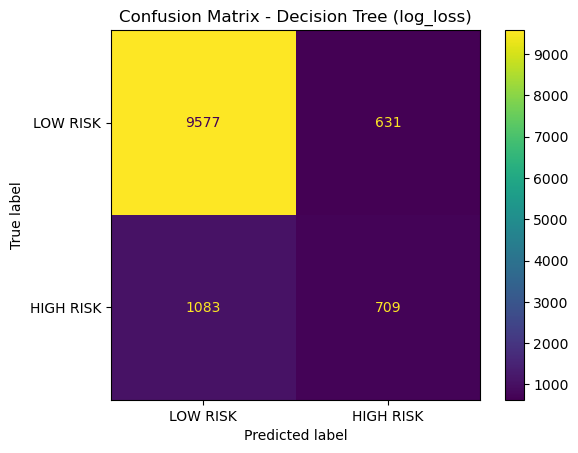

In [33]:
for model, metrics in trained_models:
    criterion = metrics["criterion"]
    matrix = np.array(metrics["confusion_matrix"])

    display_matrix = ConfusionMatrixDisplay(
        confusion_matrix=matrix,
        display_labels=["LOW RISK", "HIGH RISK"],
    )

    display_matrix.plot()
    plt.title(f"Confusion Matrix - Decision Tree ({criterion})")
    plt.show()

In [34]:
feature_importance = pd.DataFrame({
    "feature": FEATURE_COLUMNS,
    "importance": best_model.feature_importances_,
})

feature_importance = feature_importance.sort_values(
    by="importance",
    ascending=False,
).reset_index(drop=True)

feature_importance["importance"] = feature_importance["importance"].round(6)

display(feature_importance)

,feature,importance
0,tax_ratio_band,0.907283
1,price_usd,0.077295
2,tax_band,0.015422
3,weight_kg,0.000000
4,length_m,0.000000
5,width_m,0.000000
6,height_m,0.000000
7,volume_m3,0.000000
8,max_dimension_m,0.000000
9,dimension_sum_m,0.000000


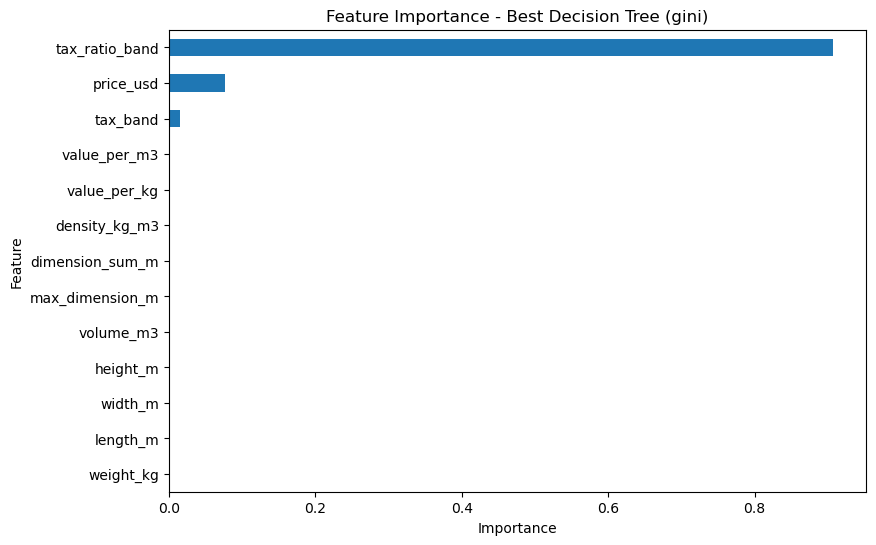

In [35]:
feature_importance.sort_values("importance").plot(
    kind="barh",
    x="feature",
    y="importance",
    legend=False,
    figsize=(9, 6),
)

plt.title(f"Feature Importance - Best Decision Tree ({best_metrics['criterion']})")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.show()

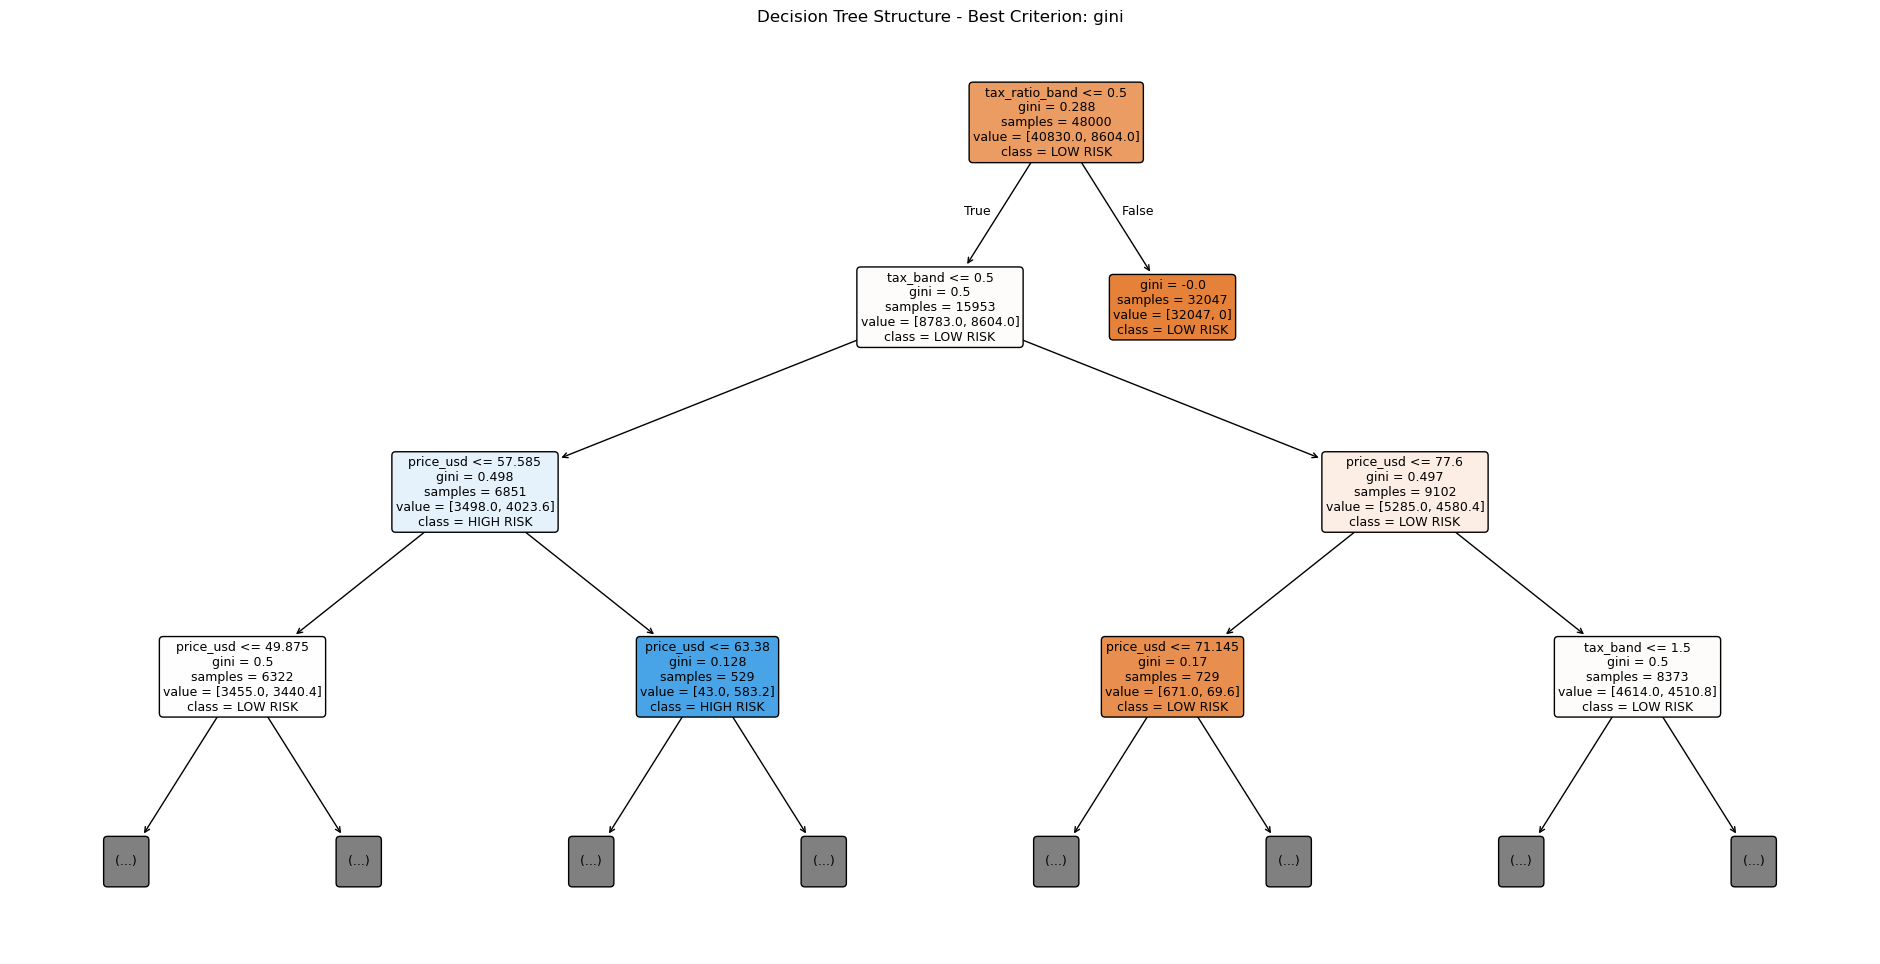

In [36]:
plt.figure(figsize=(24, 12))

plot_tree(
    best_model,
    feature_names=FEATURE_COLUMNS,
    class_names=["LOW RISK", "HIGH RISK"],
    filled=True,
    rounded=True,
    max_depth=3,
    fontsize=9,
)

plt.title(f"Decision Tree Structure - Best Criterion: {best_metrics['criterion']}")
plt.show()

In [37]:
print(best_metrics["classification_report"])

              precision    recall  f1-score   support

    LOW RISK       0.90      0.94      0.92     10208
   HIGH RISK       0.53      0.41      0.46      1792

    accuracy                           0.86     12000
   macro avg       0.72      0.67      0.69     12000
weighted avg       0.85      0.86      0.85     12000



In [38]:
def build_feature_importance(model):
    return sorted(
        [
            {
                "feature": feature,
                "importance": round(float(importance), 6),
            }
            for feature, importance in zip(FEATURE_COLUMNS, model.feature_importances_)
        ],
        key=lambda item: item["importance"],
        reverse=True,
    )


MODELS_DIR.mkdir(parents=True, exist_ok=True)

best_metrics["feature_importance"] = build_feature_importance(best_model)
best_metrics["criterion_results"] = criterion_results.to_dict(orient="records")
best_metrics["model_note"] = (
    "Decision Tree was trained without PCA for the final model. "
    "Tax and tax_ratio were retained, but transformed into tax_band and tax_ratio_band. "
    "Gini, Entropy, and Log Loss criteria were compared, and the final saved model "
    "is the best-performing criterion based on F1 Score and Accuracy."
)

joblib.dump(best_model, MODEL_PATH)

with METRICS_PATH.open("w", encoding="utf-8") as metrics_file:
    json.dump(best_metrics, metrics_file, indent=2)

with REPORT_PATH.open("w", encoding="utf-8") as report_file:
    report_file.write("Decision Tree Evaluation\n")
    report_file.write("PCA was tested but not selected for the final model.\n")
    report_file.write(f"Features: {', '.join(FEATURE_COLUMNS)}\n\n")

    report_file.write(f"Best Criterion: {best_metrics['criterion']}\n")
    report_file.write(f"Accuracy: {best_metrics['accuracy']}\n")
    report_file.write(f"Baseline Accuracy: {best_metrics['baseline_accuracy']}\n")
    report_file.write(f"Precision: {best_metrics['precision']}\n")
    report_file.write(f"Recall: {best_metrics['recall']}\n")
    report_file.write(f"F1 Score: {best_metrics['f1_score']}\n")
    report_file.write(f"Rows Used: {best_metrics['rows_used']}\n")
    report_file.write(f"Test Rows: {best_metrics['test_rows']}\n")
    report_file.write(f"Confusion Matrix: {best_metrics['confusion_matrix']}\n\n")

    report_file.write("Criterion Comparison:\n")
    for result in best_metrics["criterion_results"]:
        report_file.write(
            f"- {result['criterion']}: "
            f"accuracy={result['accuracy']}, "
            f"precision={result['precision']}, "
            f"recall={result['recall']}, "
            f"f1={result['f1_score']}\n"
        )

    report_file.write("\nFeature Importance:\n")
    for item in best_metrics["feature_importance"]:
        report_file.write(f"- {item['feature']}: {item['importance']}\n")

    report_file.write("\nClassification Report:\n")
    report_file.write(best_metrics["classification_report"])

print("Saved model:", MODEL_PATH)
print("Saved metrics:", METRICS_PATH)
print("Saved report:", REPORT_PATH)

Saved model: C:\Users\admin\Desktop\import-risk-analysis-system\ml\models\import_risk_decision_tree.joblib
Saved metrics: C:\Users\admin\Desktop\import-risk-analysis-system\ml\models\decision_tree_metrics.json
Saved report: C:\Users\admin\Desktop\import-risk-analysis-system\ml\models\decision_tree_report.txt


In [ ]:
## Conclusion

# The Decision Tree model was evaluated using three splitting criteria: Gini, 
# Entropy, and Log Loss.

# The best-performing criterion was Gini.

# PCA was tested separately, but it was not selected for the final 
# Decision Tree model because it produced unstable results for this dataset. 
# With a small number of PCA components, important information for identifying 
# HIGH RISK cases was lost. When more variance was retained, the model became 
# almost perfect again, suggesting that the tax-related signal was still strongly preserved.

# Therefore, the final Decision Tree model was trained without PCA. 
# Tax and tax_ratio were retained, but transformed into tax_band and tax_ratio_band 
# to reduce direct threshold-based learning.